# Vechta - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [148]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Universität Vechta' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/045y6d111' -- 'Universität Vechta'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [149]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Universität Vechta,University of Vechta,https://openalex.org/W4392396716
1,not assigned,Universität Vechta,Universität Vechta,https://openalex.org/W4403265524
2,not assigned,Universität Vechta,"Faculty II, University of Vechta, Vechta, Germany",https://openalex.org/W4400431061
3,not assigned,Universität Vechta,"Educational Sciences, University of Vechta, Ve...",https://openalex.org/W4399276013
4,not assigned,Universität Vechta,"University of Vechta, Department of Geography,...",https://openalex.org/W4392337652


In [2]:
MAPPING_DICT = {
    #'Bildung, Erziehung, Gesellschaft: Vechta-Institut für Inklusion': [],
    'Fakultät I': ['department of education', 'erziehungswissenschaften', 'gerontolog(ie|y)', 'soziale arbeit', 'education and social',
                   'psychology', 'faculty i,', '(educational|soci(a|eta)l) science', 'social work', 'gesellschaftswissenschaften', 'ethics',
                   'economics and sustainability', 'pedagogy', 'inclusion', 'sociology'
                  ],
    'Fakultät II': ['germanisti(k|sch)', 'geography', 'geo(-|\s)lab', 'biology', 'faculty ii', 'sport',
                    'english', 'schulpädagogik', 'cultural (sciences|studies)', 'landschaftsökologie', 'landscape ecology',
                    'kulturwissenschaften', 'natur- und sozialwissenschaften', 'agriculture', 'media research', 'geschichte', 
                    'history'
                   ],
    'Vechta Institute of Sustainability Transformation in Rural Areas': ['rural areas', 'sustainability transformation'],
    'Zentrum für Lehrer*innenbildung': ['teacher training']
}

In [3]:
with open('./mapping_tables_fak/vechta.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [351]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [352]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [353]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,None,Universität Vechta,University of Vechta,https://openalex.org/W4392396716
1,None,Universität Vechta,Universität Vechta,https://openalex.org/W4403265524
2,Fakultät II,Universität Vechta,"Faculty II, University of Vechta, Vechta, Germany",https://openalex.org/W4400431061
3,Fakultät I,Universität Vechta,"Educational Sciences, University of Vechta, Ve...",https://openalex.org/W4399276013
4,Fakultät II,Universität Vechta,"University of Vechta, Department of Geography,...",https://openalex.org/W4392337652
...,...,...,...,...
498,Fakultät II,Universität Vechta,"Lehrstuhl für Landschaftsökologie, Universität...",https://openalex.org/W3154369750
499,None,Universität Vechta,"University of Vechta Vechta, Germany",https://openalex.org/W4310734165
500,None,Universität Vechta,"University of Vechta, Germany",https://openalex.org/W4284675297
501,Fakultät II,Universität Vechta,"Department of Geography, Faculty II, Universit...",https://openalex.org/W4291825042


In [358]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()

array(['University of Vechta', 'Universität Vechta',
       'University of Vechta  Vechta Germany',
       'University of Vechta, Vechta, Germany',
       'University of Vechta, Germany',
       'Universität Vechta, Vechta, Deutschland',
       'University of Vechta , Vechta , Germany',
       'University of Vechta , Vechta , Germany , TU Dresden , Dresden , Germany , Leipzig University , Leipzig , Germany',
       'University of Vechta Vechta Germany',
       'University of Vechta, Driverstraße 22, Vechta 49377, Germany',
       'Universität Vechta  Driverstr. 22 49377 Vechta',
       'University Vechta', 'Universidad de Vechta',
       'University of Vechta, Driverstr. 22, 49364 Vechta, Germany',
       'Universität Vechta Driverstraße 22 Vechta Germany',
       'Unversity of Vechta , Vechta, Niedersachsen , Germany',
       'University of Vechta, 49377, Vechta, Germany',
       'Universität Vechta (Vechta, Germany)',
       'Universität Vechta Deutschland',
       'University of Vec

In [359]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Fakultät I,135
1,Fakultät II,130
2,Vechta Institute of Sustainability Transformat...,12
3,Zentrum für Lehrer*innenbildung,1
4,NaN,225


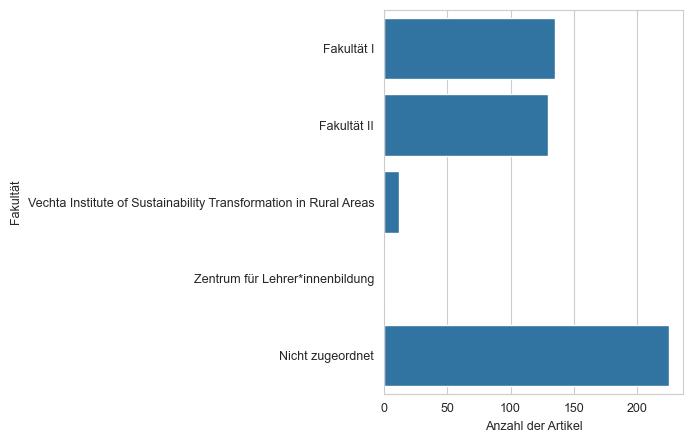

In [360]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [361]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.5526838966202783